# BIST Haber-Fiyat Etki Analizi — Keşifsel Veri Analizi (EDA)

**Amaç:** Fiyat ve KAP bildirim verisini modellemeden önce keşfetmek; veri kalitesini, getiri dağılımını, bildirim yoğunluğunu ve fiyat × haber zamanlamasını görmek. Bulgular **event study** pencere seçimini ve **sentiment skorlama**nın hedeflemesini besler.

**Kapsam:** 5 BIST hissesi (THYAO, ASELS, GARAN, KCHOL, EREGL), son ~6 ay, saatlik fiyat (yfinance) + KAP Özel Durum Açıklamaları (ÖDA).


In [1]:
from __future__ import annotations
import sys
from pathlib import Path

# src.* importlari icin proje kokunu path'e ekle (notebook nereden acilirsa acilsin)
_here = Path.cwd()
_project_root = _here if (_here / "src").exists() else _here.parent
if str(_project_root) not in sys.path:
    sys.path.insert(0, str(_project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import TICKERS, BIST_TIMEZONE
from src.analysis.loaders import load_all_prices, load_all_disclosures

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 4)
pd.set_option("display.precision", 4)
print(f"Hisseler: {list(TICKERS)}")


Hisseler: ['THYAO', 'ASELS', 'GARAN', 'KCHOL', 'EREGL']


## 1. Fiyat Verisi Sağlık Kontrolü

Satır sayısı, tarih aralığı, eksik veri ve günlük bar dağılımı.


In [2]:
prices = load_all_prices()

summary = pd.DataFrame({
    "satir": {t: len(df) for t, df in prices.items()},
    "min_tarih": {t: df.index.min().strftime("%Y-%m-%d %H:%M") for t, df in prices.items()},
    "max_tarih": {t: df.index.max().strftime("%Y-%m-%d %H:%M") for t, df in prices.items()},
    "isgun_yaklasik": {t: df.index.normalize().nunique() for t, df in prices.items()},
    "nan_close": {t: int(df["Close"].isna().sum()) for t, df in prices.items()},
})
summary["bar_per_gun"] = (summary["satir"] / summary["isgun_yaklasik"]).round(2)
summary


,satir,min_tarih,max_tarih,isgun_yaklasik,nan_close,bar_per_gun
THYAO,1118,2025-11-24 09:30,2026-05-22 17:30,125,0,8.94
ASELS,1118,2025-11-24 09:30,2026-05-22 17:30,125,0,8.94
GARAN,1118,2025-11-24 09:30,2026-05-22 17:30,125,0,8.94
KCHOL,1118,2025-11-24 09:30,2026-05-22 17:30,125,0,8.94
EREGL,1118,2025-11-24 09:30,2026-05-22 17:30,125,0,8.94


**BIST seansı (load-bearing varsayım):**

| Faz | Saat |
|---|---|
| Sürekli işlem | 10:00 – 18:00 |
| Kapanış müzayedesi | 18:00 – 18:10 |
| Nihai kapanış fiyatı | ~18:15 |

**yfinance bar etiketi notu:** Bar etiketleri Istanbul saatinde **09:30–17:30** olarak gelir (her saatin 30. dakikası — Yahoo UTC-bazlı bar etiketlemesinin sonucu) ve günlük **9 bar** oluşur. Her bar `[start, start + 1h)` aralığını kapsar:

- `09:30` bar → 09:30–10:30: **pre-opening** (09:40–10:00) + ilk 30dk sürekli işlem
- `10:30 – 16:30` → sürekli işlem saatleri
- `17:30` bar → 17:30–18:30: son 30dk işlem + **kapanış müzayedesi** (18:00–18:10) + **nihai kapanış** (~18:15) hepsi bu bar'ın `Close` alanında

Yukarıdaki tabloda `bar_per_gun ≈ 9` ise veri sağlıklı; sapma varsa eksik bar / tatil / yarım gün incelenmeli.


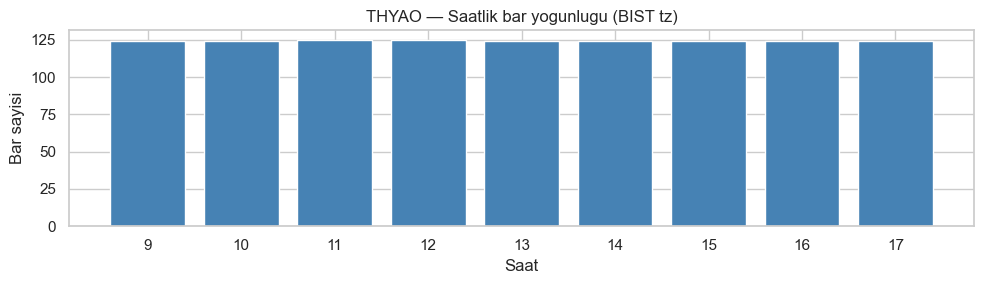

datetime
9     124
10    124
11    125
12    125
13    124
14    124
15    124
16    124
17    124


In [3]:
# Bar saatlerinin dagilimi — bir hisse ornegi
sample_ticker = list(TICKERS)[0]
sample = prices[sample_ticker]
hour_dist = sample.index.hour.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 3))
ax.bar(hour_dist.index, hour_dist.values, color="steelblue", edgecolor="white")
ax.set_title(f"{sample_ticker} — Saatlik bar yogunlugu (BIST tz)")
ax.set_xlabel("Saat")
ax.set_ylabel("Bar sayisi")
ax.set_xticks(range(int(hour_dist.index.min()), int(hour_dist.index.max()) + 1))
plt.tight_layout()
plt.show()
print(hour_dist.to_string())


## 2. Getiri Dağılımı & Volatilite


In [4]:
returns = pd.DataFrame({t: np.log(df["Close"]).diff() for t, df in prices.items()})
desc = returns.describe().T[["count", "mean", "std", "min", "max"]].copy()
desc["skew"] = returns.skew()
desc["kurt"] = returns.kurtosis()
desc.round(5)


,count,mean,std,min,max,skew,kurt
THYAO,1117.0,5.0000e-05,0.0069,-0.0623,0.0663,0.5544,20.2627
ASELS,1117.0,7.2000e-04,0.0087,-0.0401,0.0507,0.4039,3.9806
GARAN,1117.0,-8.0000e-05,0.0080,-0.0571,0.0764,0.2694,16.0598
KCHOL,1117.0,1.0000e-04,0.0068,-0.0445,0.0554,0.1294,10.5677
EREGL,1117.0,4.3000e-04,0.0076,-0.0555,0.0474,0.7732,9.0653


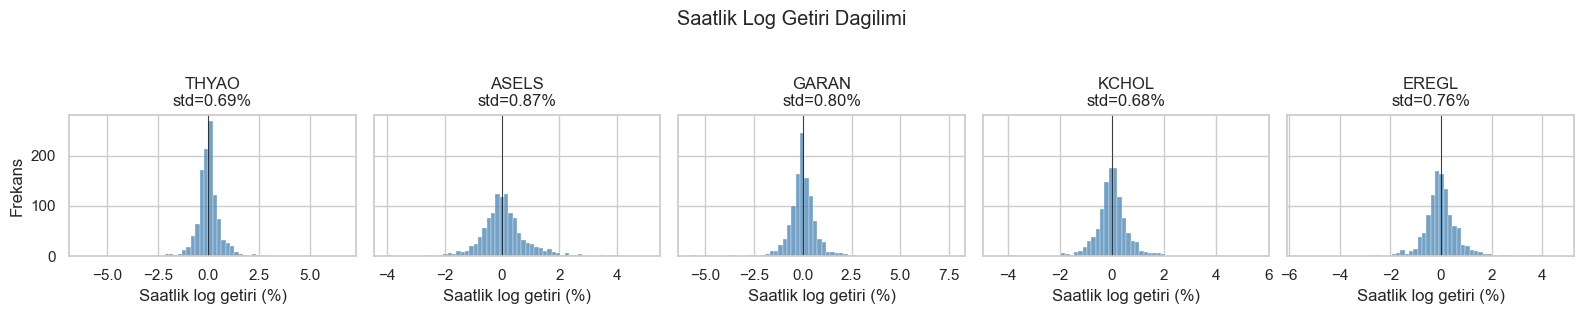

In [5]:
fig, axes = plt.subplots(1, len(TICKERS), figsize=(3.2 * len(TICKERS), 3), sharey=True)
for ax, t in zip(axes, TICKERS):
    r = returns[t].dropna() * 100
    sns.histplot(r, bins=60, ax=ax, color="steelblue", edgecolor=None)
    ax.set_title(f"{t}\nstd={r.std():.2f}%")
    ax.set_xlabel("Saatlik log getiri (%)")
    ax.axvline(0, color="black", lw=0.5)
axes[0].set_ylabel("Frekans")
plt.suptitle("Saatlik Log Getiri Dagilimi", y=1.04)
plt.tight_layout()
plt.show()


In [6]:
# Saatlik vol -> yilliklandirma: sqrt(252 trading_days x 9 bar/gun)
annualization = np.sqrt(252 * 9)
vol_table = pd.DataFrame({
    "saatlik_vol_%": (returns.std() * 100).round(3),
    "yillik_vol_%": (returns.std() * annualization * 100).round(2),
    "acf_lag1": [round(returns[t].autocorr(lag=1), 4) for t in TICKERS],
})
vol_table


,saatlik_vol_%,yillik_vol_%,acf_lag1
THYAO,0.693,33.02,-0.0155
ASELS,0.871,41.49,0.0078
GARAN,0.800,38.09,-0.0299
KCHOL,0.680,32.37,-0.0655
EREGL,0.762,36.27,-0.0604


**Yorum:** 1-bar otokorelasyon ~0 → fiyatlar etkin (efficient); ≠ 0 → momentum (pozitif) veya mean-reversion (negatif) sinyali. Event study'de abnormal getiri modelinde hesaba katılmalı.


## 3. KAP Bildirim Yoğunluğu


In [7]:
news = load_all_disclosures()

def _avg_gap(s):
    if len(s) < 2:
        return np.nan
    diffs = s.sort_values().diff().dropna().dt.total_seconds() / 86400
    return round(diffs.mean(), 1)

per_ticker = news.groupby("ticker").agg(
    bildirim=("disclosure_index", "count"),
    ilk_tarih=("publish_datetime", lambda s: s.min().strftime("%Y-%m-%d")),
    son_tarih=("publish_datetime", lambda s: s.max().strftime("%Y-%m-%d")),
).reset_index()
per_ticker["ort_gun_arasi"] = news.groupby("ticker")["publish_datetime"].apply(_avg_gap).values
per_ticker


,ticker,bildirim,ilk_tarih,son_tarih,ort_gun_arasi
0,ASELS,23,2025-12-10,2026-05-22,7.4
1,EREGL,23,2026-01-23,2026-05-22,5.4
2,GARAN,114,2025-11-25,2026-05-22,1.6
3,KCHOL,44,2025-11-25,2026-05-22,4.1
4,THYAO,28,2025-12-09,2026-05-08,5.6


C:\Users\csp\AppData\Local\Temp\ipykernel_6728\3102923034.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  news["week"] = news["publish_datetime"].dt.tz_convert(BIST_TIMEZONE).dt.to_period("W").dt.start_time


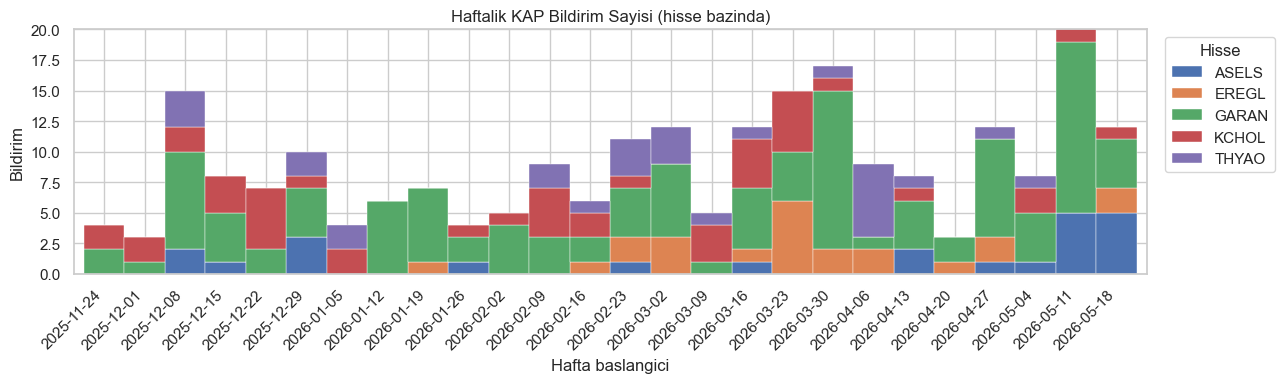

In [8]:
news["week"] = news["publish_datetime"].dt.tz_convert(BIST_TIMEZONE).dt.to_period("W").dt.start_time
weekly = news.groupby(["week", "ticker"]).size().unstack(fill_value=0)
weekly.index = [d.strftime("%Y-%m-%d") for d in weekly.index]  # str labels: matplotlib bar plot datetime ile sorun cikariyor

ax = weekly.plot(kind="bar", stacked=True, figsize=(13, 4), width=1.0, edgecolor="white", linewidth=0.3)
ax.set_title("Haftalik KAP Bildirim Sayisi (hisse bazinda)")
ax.set_xlabel("Hafta baslangici")
ax.set_ylabel("Bildirim")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Hisse", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()


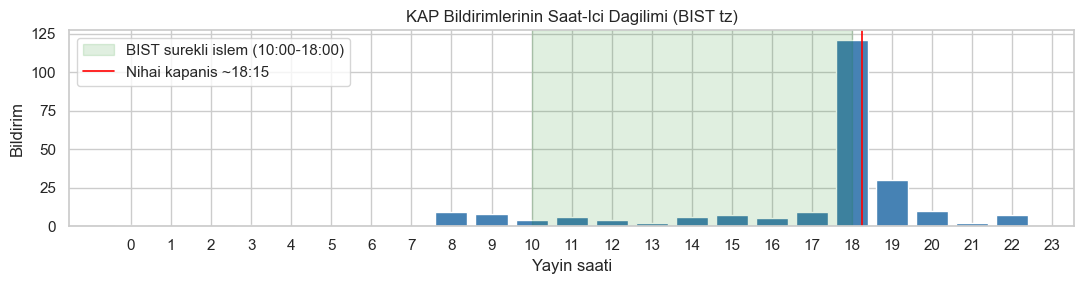

Isleme acik saatlerde (10-18): %18.5  |  disarida: %81.5


In [9]:
news["hour"] = news["publish_datetime"].dt.tz_convert(BIST_TIMEZONE).dt.hour
hour_counts = news["hour"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(11, 3))
ax.bar(hour_counts.index, hour_counts.values, color="steelblue", edgecolor="white")
ax.axvspan(10, 18, alpha=0.12, color="green", label="BIST surekli islem (10:00-18:00)")
ax.axvline(18.25, color="red", lw=1.2, label="Nihai kapanis ~18:15")
ax.set_title("KAP Bildirimlerinin Saat-Ici Dagilimi (BIST tz)")
ax.set_xlabel("Yayin saati")
ax.set_ylabel("Bildirim")
ax.set_xticks(range(0, 24))
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

icerde = ((news["hour"] >= 10) & (news["hour"] < 18)).mean() * 100
disarda = 100 - icerde
print(f"Isleme acik saatlerde (10-18): %{icerde:.1f}  |  disarida: %{disarda:.1f}")


**Yorum:** Bildirim zamanlaması event window seçimini etkiler:

- **İçeride bildirim** (10:00–18:00): saatlik bar üzerinde anında etki ölçülebilir → kısa pencere (t±1h, t±3h) anlamlı
- **Kapanış sonrası bildirim** (~18:00 sonrası): bir sonraki açılışta (~10:00 ertesi gün) gap olarak etki → t+1d window devreye girer
- **Hafta sonu bildirimi**: pazartesi açılışına kümülatif etki, ayrı kategori olarak değerlendirilebilir


In [10]:
print("Disclosure kategorisi:")
print(news["disclosure_category"].value_counts())
print("\nEn sik 10 subject:")
print(news["subject"].value_counts().head(10))

summaries = news["summary"].dropna()
summaries = summaries[summaries.str.strip() != ""]
n_sample = min(5, len(summaries))
print(f"\nOrnek {n_sample} summary:")
if n_sample > 0:
    for s in summaries.sample(n_sample, random_state=42):
        print(" -", s[:120])


Disclosure kategorisi:
disclosure_category
ODA    130
STT    102
Name: count, dtype: int64

En sik 10 subject:
subject
Özel Durum Açıklaması (Genel)                                                    70
Pay Dışında Sermaye Piyasası Aracı İşlemlerine İlişkin Bildirim (Faiz İçeren)    48
Genel Kurul İşlemlerine İlişkin Bildirim                                         16
İhraç Tavanına İlişkin Bildirim                                                  13
Kar Payı Dağıtım İşlemlerine İlişkin Bildirim                                    11
Bağımsız Denetim Kuruluşunun Belirlenmesi                                        10
Yatırım Kuruluşu Varant - Sertifika - Senetlerine İlişkin Bildirim                9
Sermaye Artırımı - Azaltımı İşlemlerine İlişkin Bildirim                          8
Kredi Derecelendirmesi                                                            8
Kurumsal Yönetim İlkelerine Uyum Derecelendirmesi                                 6
Name: count, dtype: int64

Ornek 5 summar

## 4. Fiyat × Haber Timeline — THYAO Nisan 2026

Visual sanity check: bildirim noktalarının fiyat hareketleriyle örtüşüp örtüşmediği.


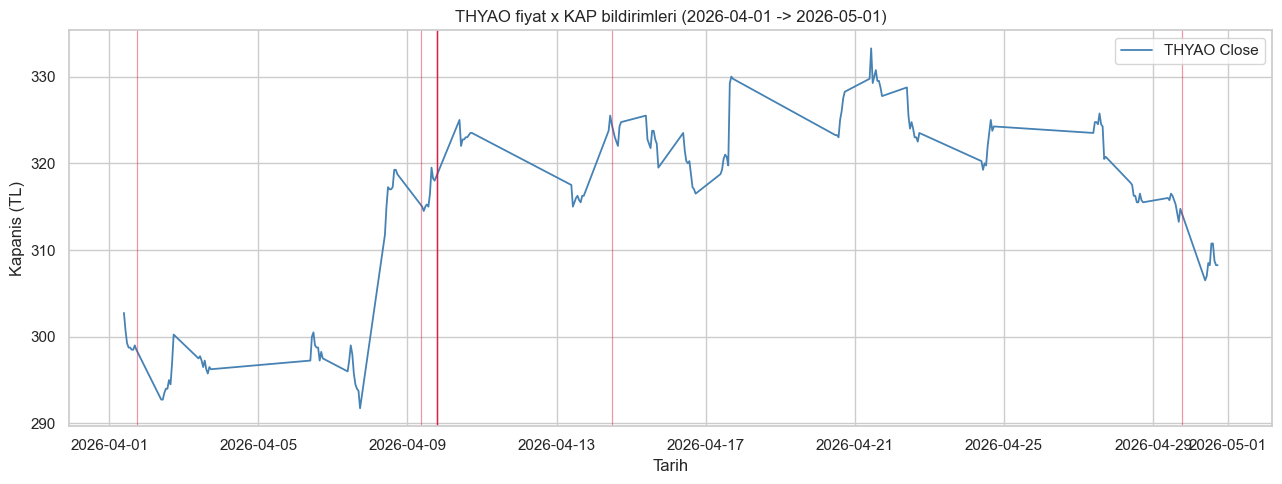


Donemde 9 KAP bildirimi (kirmizi cizgiler).



,publish_datetime,subject,summary
155,2026-04-01 17:56:00+03:00,Özel Durum Açıklaması (Genel),DB Tarımsal Enerji ve Ticaret Anonim Şirketi Y...
160,2026-04-09 08:42:55+03:00,Özel Durum Açıklaması (Genel),Mart 2026 Trafik Sonuçları
163,2026-04-09 18:59:25+03:00,Genel Kurul İşlemlerine İlişkin Bildirim,09.04.2026 tarihli 2025 Yılı Olağan Genel Kuru...
164,2026-04-09 19:11:04+03:00,Kar Payı Dağıtım İşlemlerine İlişkin Bildirim,2025 Yılı Kâr Dağıtımı ile ilgili Genel Kurul ...
165,2026-04-09 19:16:36+03:00,Özel Durum Açıklaması (Genel),Yönetim Kurulu Üye Atamaları
166,2026-04-09 19:16:51+03:00,Özel Durum Açıklaması (Genel),Yönetim Kurulu Komite Ataması
167,2026-04-09 19:17:12+03:00,Özel Durum Açıklaması (Genel),Üst Yönetim Değişikliği
170,2026-04-14 11:55:13+03:00,Genel Kurul İşlemlerine İlişkin Bildirim,Olağan Genel Kurul Toplantı Kararlarının Tescili
187,2026-04-29 18:21:33+03:00,Özel Durum Açıklaması (Genel),2026 1. Çeyrek Finansal Sonuçlar


In [11]:
ticker = "THYAO"
window_start = pd.Timestamp("2026-04-01", tz=BIST_TIMEZONE)
window_end = pd.Timestamp("2026-05-01", tz=BIST_TIMEZONE)

p = prices[ticker].loc[window_start:window_end]
n = news[
    (news["ticker"] == ticker)
    & (news["publish_datetime"].between(window_start, window_end))
]

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(p.index, p["Close"], lw=1.3, color="steelblue", label=f"{ticker} Close")
for _, row in n.iterrows():
    ax.axvline(row["publish_datetime"], color="crimson", alpha=0.45, lw=0.9)
ax.set_title(f"{ticker} fiyat x KAP bildirimleri ({window_start.date()} -> {window_end.date()})")
ax.set_xlabel("Tarih")
ax.set_ylabel("Kapanis (TL)")
ax.legend(loc="best")
plt.tight_layout()
plt.show()

print(f"\nDonemde {len(n)} KAP bildirimi (kirmizi cizgiler).\n")
n[["publish_datetime", "subject", "summary"]].head(15)


## 5. Özet Bulgular (run sonrası doldur)

Notebook'u çalıştırdıktan sonra somut sayıları aşağıya işle:

| Boyut | Bulgu | Sonraki adıma etkisi |
|---|---|---|
| Veri sağlığı | (eksik bar / hisse, tarih kapsamı) | event window içinde minimum bar garantisi |
| Getiri/volatilite | (saatlik std, yıllık vol, ACF lag-1 işareti) | abnormal getiri için baz model seçimi (pazar modeli mi, sabit mi?) |
| KAP zamanlaması | (içeride/dışarıda yüzdesi) | t±Nh vs t+1d window oranı |
| KAP içerik | (ÖDA kategorisi dağılımı, en sık subject'ler) | sentiment hedeflemesi: hangi konular skorlanmaya değer |

**Sonraki adım:** Bulguların ışığında `src/analysis/event_study.py` iskeleti — bildirim t₀ etrafında pencere kes, hisse getirisi vs. (BIST100 referansı opsiyonel) abnormal getiri/CAR hesabı.
